# Inverse Design of a Polarization-Basis 2x2 Unitary Operator

In [1]:
# Section 1 - Imports

from typing import List

import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np
import scipy as sp

import tidy3d as td
import tidy3d.web as web
from autograd import value_and_grad

from tidy3d.plugins.autograd import (
    make_filter_and_project,
    make_erosion_dilation_penalty,
    rescale,
)
from tidy3d.plugins.mode import ModeSolver

In [2]:
# Section 2 - Parameters
#
# The opt/final pairs below split "cheap optimization" settings from "strict
# verification" settings. The opt loop in Section 15 uses the *_opt values; the
# verification cells in Sections 17-19 override make_adjoint_sim with the *_final
# values so the report card uses high-fidelity numbers.

# Wavelength / spectrum
wl = 1.55                       # Central wavelength (um) - telecom C-band
bw = 0.020                      # Bandwidth (um)
n_wl = 2                        # Wavelength samples in bandwidth

# Materials (Si on SiO2, air cladding)
nSi = 3.476                     # Crystalline Si at 1550 nm
nSiO2 = 1.444                   # Thermal SiO2 at 1550 nm

# Waveguide cross-section (standard SOI 220 nm Si layer)
w_thick = 0.22                  # Si layer thickness (um)
w_width = 0.50                  # Waveguide width (um) - supports TE0 and TM0
w_length = 0.5                  # Input/output stub length (um) between PML and design region
box_thick = 1.0                 # SiO2 BOX thickness (um) - mode evanescent tail < 0.5 um

# Design region
gc_length = 12.0                # Active design length in x (um)
gc_width  = 6.0                 # Active design width in y (um)
dr_grid_size = 0.030            # Design-parameter pixel grid (um); kept at 30 nm to preserve any existing checkpoint
fdtd_design_dl = 0.040          # FDTD mesh override inside the design region (um); ~2.5 cells per 100 nm feature
border_buffer = 0.16            # Border (no-design) margin on each side (um)

# Fabrication / filter
min_feature_size = 0.100        # 100 nm minimum feature size in Si
filter_radius = min_feature_size

# Projection sharpness
beta_min = 1.0
beta_max = 25.0
beta_ramp_start = 25            # Hold beta=1 for the first 50 iterations before ramping
beta_ramp_end   = 100           # Beta reaches beta_max here; hold flat for remaining iters

# Optimization
it_per_step = 1
opt_steps = 120                 # Total iterations
learning_rate = 0.1

# Objective weights -----------------------------------------------------------
lambda_pen   = 0.2              # Fabrication penalty
lambda_trans = 0.3              # Reward total transmission; term in [0, 1]
# -----------------------------------------------------------------------------

# Cost-control knobs ---------------------------------------------------------
shutoff_opt           = 1e-4    # Early-shutoff field-energy ratio during opt
min_steps_per_wvl_opt = 12      # FDTD cells per wavelength outside design region during opt
num_freqs_src_opt     = 1       # ModeSource freq sampling during opt
run_time_opt          = 5e-12   # Hard time ceiling during opt

# Strict settings for the verification cells.
shutoff_final           = 1e-5
min_steps_per_wvl_final = 15
num_freqs_src_final     = 5
run_time_final          = 6e-12
# ----------------------------------------------------------------------------

# Mode-index convention - filled in by the calibration cell (Section 6)
mode_index_TE = 0
mode_index_TM = 1

# History checkpoint
history_fname = "misc/polarization_unitary_history_v5.pkl"

total_iter = opt_steps * it_per_step
print(f"Total iterations = {total_iter}")
print(f"Beta schedule: hold beta={beta_min} for iters 0-{beta_ramp_start-1}, "
      f"ramp to beta={beta_max} by iter {beta_ramp_end}, hold flat thereafter.")

Total iterations = 120
Beta schedule: hold beta=1.0 for iters 0-24, ramp to beta=25.0 by iter 100, hold flat thereafter.


In [3]:
# Section 3 - Derived quantities

# Permittivities.
eps_max = nSi ** 2
eps_min = 1.0

# Materials.
mat_si   = td.Medium(permittivity=eps_max)
mat_sio2 = td.Medium(permittivity=nSiO2 ** 2)

# Frequencies.
wl_max = wl + bw / 2
wl_min = wl - bw / 2
wl_range = np.linspace(wl_min, wl_max, n_wl)
freq  = td.C_0 / wl
freqs = td.C_0 / wl_range
freqw = 0.5 * (freqs[0] - freqs[-1])

# Design-region pixel grid.
nx = int((gc_length + 2 * border_buffer) / dr_grid_size)
ny = int((gc_width  + 2 * border_buffer) / dr_grid_size)
npar = nx * ny
dr_size_x = nx * dr_grid_size
dr_size_y = ny * dr_grid_size

# Computational domain: input stub + design region + output stub + PML padding both ends.
pml_spacing = 0.6 * wl
size_x = dr_size_x + 2 * w_length + 2 * pml_spacing
size_y = dr_size_y + 2 * pml_spacing
size_z = w_thick + box_thick + 2 * pml_spacing

# Place the design region symmetrically about x = 0.
dr_center_x = 0.0
center_z = size_z / 2 - pml_spacing - w_thick / 2  # shift in -z so air cladding sits above the slab

eff_inf = 1000

# Source / monitor positions in the input and output stubs (well clear of PMLs).
mon_pos_x_in  = -dr_size_x / 2 - 0.5 * w_length
mon_pos_x_out =  dr_size_x / 2 + 0.5 * w_length
mon_w = max(w_width * 5, 2.0)
mon_h = max(w_thick * 6, 1.5)

# Interface-buffer indexing: a horizontal strip of full Si at the left and right design-region edges.
n_border  = int(border_buffer / dr_grid_size)
n_wg_half = int((w_width / 2) / dr_grid_size)
n_y_center = ny // 2            # central WG sits at y = 0

print(f"Design region : {dr_size_x:.2f} um x {dr_size_y:.2f} um")
print(f"Grid nx x ny  : {nx} x {ny} = {npar:,} parameters")
print(f"Sim domain    : {size_x:.2f} x {size_y:.2f} x {size_z:.2f} um")


Design region : 12.30 um x 6.30 um
Grid nx x ny  : 410 x 210 = 86,100 parameters
Sim domain    : 15.16 x 8.16 x 3.08 um


In [4]:
# Section 4 - Static structures (waveguides, BOX)

# Input WG stub: x in [-inf, -dr_size_x/2], width w_width, thickness w_thick.
waveguide_in = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf,         -w_width / 2, -w_thick / 2),
        rmax=(-dr_size_x / 2,    w_width / 2,  w_thick / 2),
    ),
    medium=mat_si,
)

# Output WG stub: x in [dr_size_x/2, +inf].
waveguide_out = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=( dr_size_x / 2,   -w_width / 2, -w_thick / 2),
        rmax=( eff_inf,          w_width / 2,  w_thick / 2),
    ),
    medium=mat_si,
)

# SiO2 BOX directly under the slab.
sio2_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -w_thick / 2 - box_thick),
        rmax=( eff_inf,  eff_inf, -w_thick / 2),
    ),
    medium=mat_sio2,
)

# Si bulk substrate below the BOX (treated as Si).
si_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -eff_inf),
        rmax=( eff_inf,  eff_inf, -w_thick / 2 - box_thick),
    ),
    medium=mat_si,
)

In [5]:
# Section 5 - Sources and output mode monitor
#
# Both modes are excited through the SAME plane. We build two ModeSource objects, one
# for TE input and one for TM input; obj() runs them as two separate simulations.
# A single ModeMonitor at the output plane records the complex amplitudes of both
# modes for whichever input was active.

mode_spec_2 = td.ModeSpec(num_modes=2, target_neff=nSi)

# Source TE: excites mode_index_TE only.
src_TE = td.ModeSource(
    center=[mon_pos_x_in, 0, 0],
    size=[0, mon_w, mon_h],
    source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
    mode_spec=mode_spec_2,
    mode_index=mode_index_TE,
    direction="+",
    num_freqs=5,
)

# Source TM: excites mode_index_TM only.
src_TM = td.ModeSource(
    center=[mon_pos_x_in, 0, 0],
    size=[0, mon_w, mon_h],
    source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
    mode_spec=mode_spec_2,
    mode_index=mode_index_TM,
    direction="+",
    num_freqs=5,
)

sources = {"TE": src_TE, "TM": src_TM}

# Output monitor: records amplitudes of mode_index 0 and 1, propagating in +x.
out_monitor = td.ModeMonitor(
    center=[mon_pos_x_out, 0, 0],
    size=[0, mon_w, mon_h],
    freqs=[freq],
    mode_spec=mode_spec_2,
    name="out_amps",
)

# Broadband version used in the final verification section to plot insertion loss vs wavelength.
out_monitor_bb = td.ModeMonitor(
    center=[mon_pos_x_out, 0, 0],
    size=[0, mon_w, mon_h],
    freqs=list(freqs),
    mode_spec=mode_spec_2,
    name="out_amps_bb",
)

# Optional field monitor for visualizing the steady-state field in the slab plane.
field_xy = td.FieldMonitor(
    center=[0, 0, 0],
    size=[td.inf, td.inf, 0],
    freqs=[freq],
    name="field_xy",
)

21:03:03 PDT WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.web.run(...)' or the deprecated    
             'tidy3d.plugins.mode.web.run(...)'.                                

mode_index = 0: neff = 2.3877,  |Ey|^2 frac = 0.712,  |Ez|^2 frac = 0.013
mode_index = 1: neff = 1.6142,  |Ey|^2 frac = 0.069,  |Ez|^2 frac = 0.619

Assigned mode_index_TE = 0,  mode_index_TM = 1


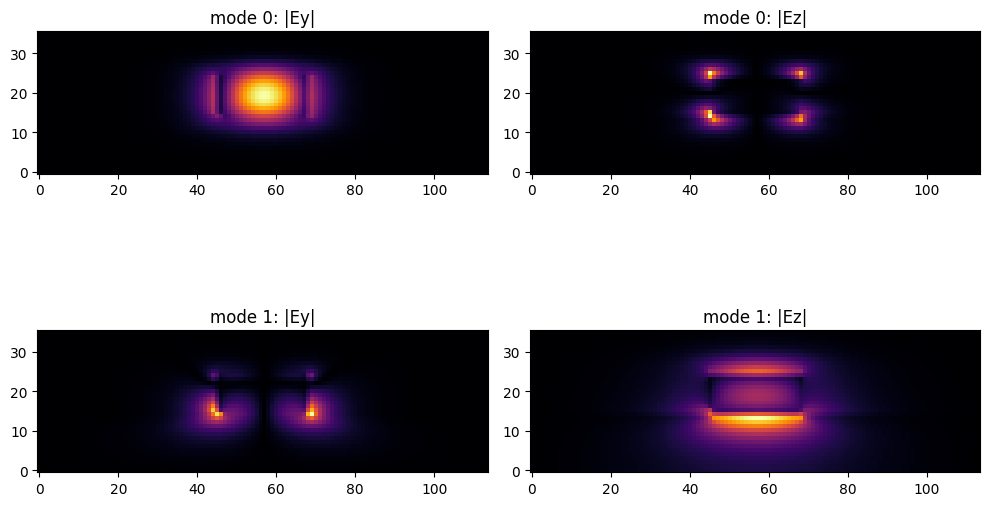

In [6]:
# Section 6 - Mode-solver calibration cell
#
# tidy3d sorts modes by descending effective index. For a 220 nm x 500 nm Si-on-SiO2
# strip waveguide at 1550 nm, TE0 has the higher neff so mode_index_TE = 0 and
# mode_index_TM = 1. We verify this empirically: compute the modal fields at the
# input plane and assign indices by which polarization dominates (|Ey| vs |Ez|).

def _solve_input_modes():
    """Return mode_data from a ModeSolver run on the input waveguide cross-section."""
    # Build a minimal simulation that contains only the static structures - the
    # ModeSolver needs a simulation to anchor its grid.
    cal_sim = td.Simulation(
        size=[size_x, size_y, size_z],
        center=[0, 0, -center_z],
        grid_spec=td.GridSpec.auto(wavelength=wl, min_steps_per_wvl=20),
        structures=[waveguide_in, waveguide_out, sio2_substrate, si_substrate],
        sources=[],
        monitors=[],
        run_time=run_time_final,
    )
    plane = td.Box(center=[mon_pos_x_in, 0, 0], size=[0, mon_w, mon_h])
    ms = ModeSolver(simulation=cal_sim, plane=plane, mode_spec=mode_spec_2, freqs=[freq])
    return ms.solve()

mode_data_cal = _solve_input_modes()

def _pol_fractions(mode_data, idx):
    """Return (te_frac, tm_frac) for mode `idx` at the calibration frequency.

    te_frac = integral(|Ey|^2) / integral(|E|^2)
    tm_frac = integral(|Ez|^2) / integral(|E|^2)
    """
    Ey = np.asarray(mode_data.Ey.isel(f=0, mode_index=idx).values).squeeze()
    Ez = np.asarray(mode_data.Ez.isel(f=0, mode_index=idx).values).squeeze()
    Ex = np.asarray(mode_data.Ex.isel(f=0, mode_index=idx).values).squeeze()
    P_total = float(np.sum(np.abs(Ex) ** 2 + np.abs(Ey) ** 2 + np.abs(Ez) ** 2))
    te = float(np.sum(np.abs(Ey) ** 2)) / P_total
    tm = float(np.sum(np.abs(Ez) ** 2)) / P_total
    return te, tm

# Print effective indices and polarization composition.
neff_arr = np.asarray(mode_data_cal.n_eff.values).squeeze()
for i in range(2):
    te, tm = _pol_fractions(mode_data_cal, i)
    print(f"mode_index = {i}: neff = {neff_arr[i]:.4f},  |Ey|^2 frac = {te:.3f},  |Ez|^2 frac = {tm:.3f}")

# Assign TE/TM index from the polarization fractions (override defaults from Section 2).
_te_frac0, _tm_frac0 = _pol_fractions(mode_data_cal, 0)
_te_frac1, _tm_frac1 = _pol_fractions(mode_data_cal, 1)
mode_index_TE = 0 if _te_frac0 > _te_frac1 else 1
mode_index_TM = 1 - mode_index_TE
print(f"\nAssigned mode_index_TE = {mode_index_TE},  mode_index_TM = {mode_index_TM}")

# Rebuild the two ModeSource objects with the correct mode_index assignments.
src_TE = src_TE.updated_copy(mode_index=mode_index_TE)
src_TM = src_TM.updated_copy(mode_index=mode_index_TM)
sources = {"TE": src_TE, "TM": src_TM}

# Plot the mode profiles to confirm by eye.
fig, axes = plt.subplots(2, 2, figsize=(10, 7), tight_layout=True)
for i in range(2):
    Ey = np.asarray(mode_data_cal.Ey.isel(f=0, mode_index=i).values).squeeze()
    Ez = np.asarray(mode_data_cal.Ez.isel(f=0, mode_index=i).values).squeeze()
    axes[i, 0].imshow(np.abs(Ey).T, origin="lower", cmap="inferno")
    axes[i, 0].set_title(f"mode {i}: |Ey|")
    axes[i, 1].imshow(np.abs(Ez).T, origin="lower", cmap="inferno")
    axes[i, 1].set_title(f"mode {i}: |Ez|")
plt.show()

In [7]:
# Section 7 - Initial parameters
#
# Random uniform field, smoothed with a Gaussian kernel so the initial design is
# slowly varying rather than salt-and-pepper noise. No y-symmetry enforcement -
# Hadamard requires mixing TE <-> TM, which generally needs an asymmetric pattern.

init_par = np.random.uniform(0, 1, npar)
init_par = sp.ndimage.gaussian_filter(init_par, 1.5).reshape((nx, ny))

In [8]:
# Section 8 - Autograd-aware preprocessing pipeline

filter_project = make_filter_and_project(filter_radius, dr_grid_size, padding="constant")

def interface_buffer(params):
    """Force rho = 1 in a w_width strip at BOTH the left and right design-region edges
    so the input and output Si waveguide stubs always couple into solid Si."""
    mask = np.zeros_like(params)
    mask[0:n_border,       n_y_center - n_wg_half : n_y_center + n_wg_half + 1] = 1
    mask[nx - n_border:nx, n_y_center - n_wg_half : n_y_center + n_wg_half + 1] = 1
    return params * (1 - mask) + mask

def pre_process(params, beta):
    params1 = interface_buffer(params)
    params2 = filter_project(params1, beta=beta)
    params3 = filter_project(params2, beta=beta)
    return params3

def get_eps_values(params, beta):
    params = pre_process(params, beta=beta)
    return rescale(params, eps_min, eps_max)

def get_eps(design_param, beta=1.0, binarize=False):
    eps = get_eps_values(design_param, beta=beta)
    if binarize:
        eps = anp.where(eps < (eps_min + eps_max) / 2, eps_min, eps_max)
    else:
        eps = anp.where(eps < eps_min, eps_min, eps)
        eps = anp.where(eps > eps_max, eps_max, eps)
    return eps

In [9]:
# Section 9 - update_design: build CustomMedium structure from eps array

def update_design(eps) -> List[td.Structure]:
    eps_val = anp.array(eps).reshape((nx, ny, 1))
    coords_x = [(-dr_size_x / 2) + (ix + 0.5) * dr_grid_size for ix in range(nx)]
    coords_y = [(-dr_size_y / 2) + (iy + 0.5) * dr_grid_size for iy in range(ny)]
    coords = dict(x=coords_x, y=coords_y, z=[0])
    permittivity = td.SpatialDataArray(eps_val, coords=coords)
    eps_medium = td.CustomMedium(permittivity=permittivity)
    box = td.Box(center=(dr_center_x, 0, 0), size=(dr_size_x, dr_size_y, w_thick))
    return [td.Structure(geometry=box, medium=eps_medium)]

In [10]:
# Section 10 - make_adjoint_sim: assemble one simulation for one input polarization

def make_adjoint_sim(
    design_param: np.ndarray,
    beta: float = 1.0,
    source: str = "TE",
    binarize: bool = False,
    shutoff: float = None,
    min_steps_per_wvl: int = None,
    num_freqs_src: int = None,
    run_time_sim: float = None,
) -> td.Simulation:
    """One forward simulation with a single ModeSource ('TE' or 'TM').

    The output ModeMonitor always records both mode_index 0 and 1, so a single FDTD
    run yields one column of U_meas. Two such runs (TE input, TM input) yield the
    full 2x2 matrix.

    Cost-control kwargs default to the opt-loop values from Section 2; the
    verification cells override them with the *_final values to get a strict
    high-fidelity report card.
    """
    if shutoff is None:
        shutoff = shutoff_opt
    if min_steps_per_wvl is None:
        min_steps_per_wvl = min_steps_per_wvl_opt
    if num_freqs_src is None:
        num_freqs_src = num_freqs_src_opt
    if run_time_sim is None:
        run_time_sim = run_time_opt

    eps = get_eps(design_param, beta, binarize)
    design_structure = update_design(eps)

    # Coarsen the FDTD mesh inside the design region to fdtd_design_dl. The
    # design parameter grid stays at dr_grid_size so the existing checkpoint
    # remains valid; CustomMedium gets sampled onto this coarser FDTD grid.
    adjoint_dr_mesh = td.MeshOverrideStructure(
        geometry=td.Box(center=(dr_center_x, 0, 0), size=(dr_size_x, dr_size_y, w_thick)),
        dl=[fdtd_design_dl, fdtd_design_dl, fdtd_design_dl],
        enforce=True,
    )

    src = sources[source].updated_copy(num_freqs=num_freqs_src)

    return td.Simulation(
        size=[size_x, size_y, size_z],
        center=[0, 0, -center_z],
        grid_spec=td.GridSpec.auto(
            wavelength=wl_max,
            min_steps_per_wvl=min_steps_per_wvl,
            override_structures=[adjoint_dr_mesh],
        ),
        symmetry=(0, 0, 0),         # TE and TM have opposite parities; no symmetry exploitation
        structures=[waveguide_in, waveguide_out, sio2_substrate, si_substrate] + design_structure,
        sources=[src],
        monitors=[out_monitor],
        run_time=run_time_sim,
        shutoff=shutoff,
        subpixel=True,
    )

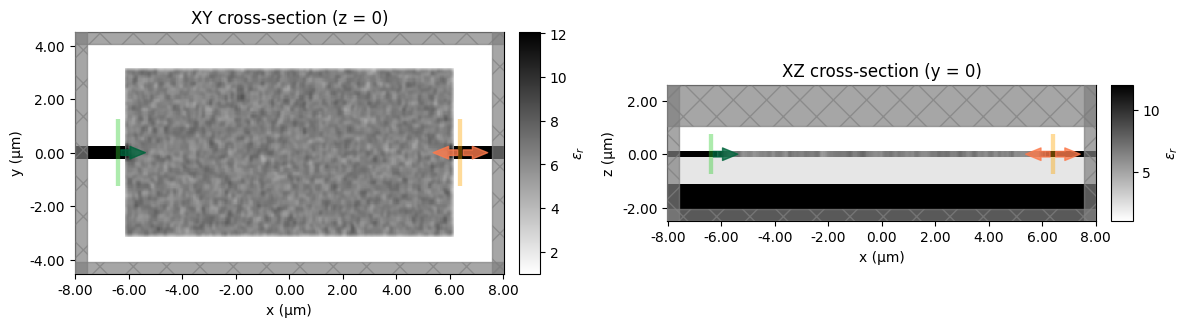

21:03:07 PDT Created task 'cost_test' with resource_id                          
             'fdve-27945685-9325-4747-8d64-b8fb8a450c9b' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=32239;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27945685-9325-4747-8d64-b8fb8a450c9b\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=644247;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27945685-9325-4747-8d64-b8fb8a450c9b\taskId]8;;\]8;id=32239;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27945685-9325-4747-8d64-b8fb8a450c9b\=]8;;\]8;id=228017;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27945685-9325-4747-8d64-b8fb8a450c9b\fdve]8;;\]8;id=32239;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27945685-9325-4747-8d64-b8fb8a450c9b\-27945685-932]8;;\
             ]8;id=32239;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27945685-9325-4747-8d64-b8fb8a450c9b\5-4747-8d64-b8fb8a450c9b']8;;\.

             Task folder: ]8;id=491459;https://tidy3d.simulation.cloud/folders/folder-7235af3d-4647-4197-8600-06fd43d27c0f\'default']8;;\.

Output()

21:03:08 PDT Estimated FlexCredit cost: 0.173. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

21:03:09 PDT Estimated FlexCredit cost: 0.173. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

Cost per simulation  : 0.173 FlexCredits
Sims per iteration   : 2  (TE input, TM input)
Estimated total cost : 41.44 FlexCredits  (120 iterations)


In [11]:
# Section 11 - Visualization of the initial design + cost estimate

init_design = make_adjoint_sim(init_par, beta=beta_min, source="TE")

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(12, 5))
init_design.plot_eps(z=0, ax=ax1)
ax1.set_title("XY cross-section (z = 0)")
init_design.plot_eps(y=0, ax=ax2)
ax2.set_title("XZ cross-section (y = 0)")
plt.show()

# 3D preview (interactive).
init_design.plot_3d()

# Cost estimate per simulation x 2 sims/iter x total_iter iterations.
sim_cost_test = web.Job(simulation=init_design, task_name="cost_test")
estimated_cost = web.estimate_cost(sim_cost_test.task_id)
print(f"Cost per simulation  : {estimated_cost:.3f} FlexCredits")
print(f"Sims per iteration   : 2  (TE input, TM input)")
print(f"Estimated total cost : {estimated_cost * 2 * opt_steps:.2f} FlexCredits  ({opt_steps} iterations)")


In [12]:
# Section 12 - Target unitary and helpers

def hadamard():
    return (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)

def pauli_x():
    return np.array([[0, 1], [1, 0]], dtype=complex)

def pauli_z():
    return np.array([[1, 0], [0, -1]], dtype=complex)

def rotator(alpha):
    """Polarization rotator by angle alpha (mixes TE and TM as a real rotation)."""
    c, s = np.cos(alpha), np.sin(alpha)
    return np.array([[c, -s], [s, c]], dtype=complex)

def retarder(phi):
    """Phase retarder: identity on TE, e^{i phi} on TM."""
    return np.array([[1.0, 0.0], [0.0, np.exp(1j * phi)]], dtype=complex)

def is_unitary(U, tol=1e-9):
    return np.allclose(U.conj().T @ U, np.eye(U.shape[0]), atol=tol)

# Pick the Hadamard target.
U_target = hadamard()
assert is_unitary(U_target), "U_target is not unitary."
print("U_target (Hadamard) =")
print(U_target)

U_target (Hadamard) =
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]


In [13]:
# Section 13 - Objective function
#
# J = |Tr(U_target^H U_meas)|^2          (gauge-invariant fidelity, peak 4)
#   + lambda_trans * ||U_meas||_F^2 / 2  (reward total transmission, target 1)
#   - lambda_pen   * fab_penalty
#
# J_max ≈ 4 (fidelity) + lambda_trans (trans reward at lossless) for a perfect Hadamard.

erode_dilate_penalty = make_erosion_dilation_penalty(filter_radius, dr_grid_size)

def get_column(sim_data):
    """Return (a_TE_out, a_TM_out) complex amplitudes at the output ModeMonitor."""
    amps = sim_data["out_amps"].amps.sel(direction="+", f=freq)
    a_TE = amps.sel(mode_index=mode_index_TE).values
    a_TM = amps.sel(mode_index=mode_index_TM).values
    return anp.stack([a_TE, a_TM])

def penalty(params, beta):
    return erode_dilate_penalty(pre_process(params, beta=beta))

def obj(design_param, beta=1.0, step_num=None, verbose=False):
    """One full evaluation: two FDTD runs (TE input, TM input), build U_meas, return FOM."""
    suffix = f"_step_{step_num}" if step_num is not None else ""

    sim_TE = make_adjoint_sim(design_param, beta, source="TE")
    data_TE = web.run(sim_TE, task_name=f"unitary_TE{suffix}", verbose=verbose)
    col_TE = get_column(data_TE)                    # column for TE input

    sim_TM = make_adjoint_sim(design_param, beta, source="TM")
    data_TM = web.run(sim_TM, task_name=f"unitary_TM{suffix}", verbose=verbose)
    col_TM = get_column(data_TM)                    # column for TM input

    # U_meas[i, j] = output of mode i when input is mode j.
    U_meas = anp.stack([col_TE, col_TM], axis=1)

    # Gauge-invariant fidelity: |Tr(U_target^H U_meas)|^2, peak 4.
    inner = anp.sum(anp.conj(U_target) * U_meas)
    fidelity_metric = anp.abs(inner) ** 2

    # Total transmission: ||U_meas||_F^2 / 2, target 1 (lossless).
    transmission = anp.sum(anp.abs(U_meas) ** 2) / 2.0

    J = (fidelity_metric
         + lambda_trans * transmission
         - lambda_pen   * penalty(design_param, beta=beta))
    return J

obj_grad = value_and_grad(obj)

In [16]:
# Section 14 - Optimizer and checkpointing

import os
import pickle
import optax

os.makedirs("misc", exist_ok=True)
os.makedirs("data", exist_ok=True)

optimizer = optax.adam(learning_rate=learning_rate)

def save_history(history_dict):
    with open(history_fname, "wb") as f:
        pickle.dump(history_dict, f)

def load_history():
    with open(history_fname, "rb") as f:
        return pickle.load(f)

try:
    history_dict = load_history()
    opt_state = history_dict["opt_states"][-1]
    params = history_dict["params"][-1]
    num_done = len(history_dict["params"])
    print(f"Loaded checkpoint: {num_done} / {total_iter} iterations done.")
    if num_done < total_iter:
        print("Resuming optimization.")
    else:
        print("Optimization already complete.")
except FileNotFoundError:
    params = np.array(init_par)
    opt_state = optimizer.init(params)
    history_dict = dict(values=[], params=[], gradients=[], opt_states=[opt_state], beta=[])
    print("No checkpoint found - starting fresh.")

Loaded checkpoint: 35 / 120 iterations done.
Resuming optimization.


In [17]:
# Section 15 - Optimization loop

iter_done = len(history_dict["values"])

for i in range(iter_done, total_iter):
    print(f"Iteration {i + 1} / {total_iter}")

    # Beta schedule:
    #   iters 0 .. beta_ramp_start-1  : beta = beta_min  (soft, topology finding)
    #   iters beta_ramp_start .. beta_ramp_end-1 : linear ramp beta_min -> beta_max
    #   iters beta_ramp_end .. total_iter-1      : beta = beta_max  (hold, binary polish)
    if i < beta_ramp_start:
        beta_i = beta_min
    elif i < beta_ramp_end:
        frac = (i - beta_ramp_start) / (beta_ramp_end - beta_ramp_start)
        beta_i = beta_min + (beta_max - beta_min) * frac
    else:
        beta_i = beta_max

    value, gradient = obj_grad(params, beta=beta_i, step_num=i)

    print(f"  beta = {beta_i:.2f}    J = {value:.4e}    |grad| = {np.linalg.norm(gradient):.4e}")

    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params = optax.apply_updates(params, updates)
    params = np.clip(params, 0.0, 1.0)

    history_dict["values"].append(value)
    history_dict["params"].append(params.copy())
    history_dict["beta"].append(beta_i)
    history_dict["gradients"].append(gradient)
    history_dict["opt_states"].append(opt_state)
    save_history(history_dict)

Iteration 36 / 120
  beta = 4.20    J = 1.5688e+00    |grad| = 5.9115e-01
Iteration 37 / 120
  beta = 4.52    J = 1.3571e+00    |grad| = 9.1399e-01
Iteration 38 / 120
  beta = 4.84    J = 1.5478e+00    |grad| = 9.0111e-01
Iteration 39 / 120
  beta = 5.16    J = 1.2604e+00    |grad| = 1.5652e+00
Iteration 40 / 120
  beta = 5.48    J = 1.0278e+00    |grad| = 8.8830e-01
Iteration 41 / 120
  beta = 5.80    J = 1.5505e+00    |grad| = 7.7032e-01
Iteration 42 / 120
  beta = 6.12    J = 1.1316e+00    |grad| = 9.8858e-01
Iteration 43 / 120
  beta = 6.44    J = 1.3998e+00    |grad| = 9.1976e-01
Iteration 44 / 120
  beta = 6.76    J = 7.2013e-01    |grad| = 9.7929e-01
Iteration 45 / 120
  beta = 7.08    J = 8.4583e-01    |grad| = 4.5582e-01
Iteration 46 / 120
  beta = 7.40    J = 1.1175e+00    |grad| = 5.4913e-01
Iteration 47 / 120
  beta = 7.72    J = 1.0973e+00    |grad| = 8.5455e-01
Iteration 48 / 120
  beta = 8.04    J = 8.8468e-01    |grad| = 9.7062e-01
Iteration 49 / 120
  beta = 8.36    J 

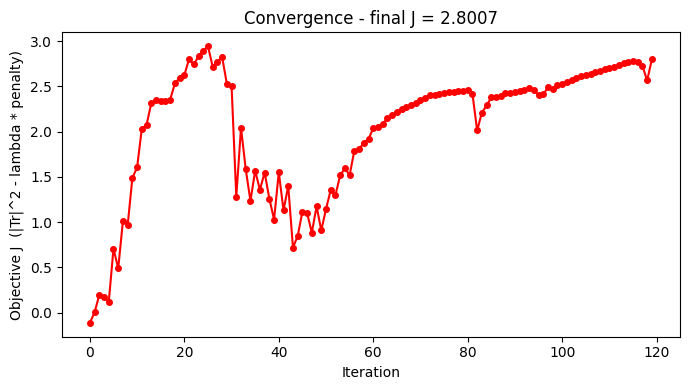

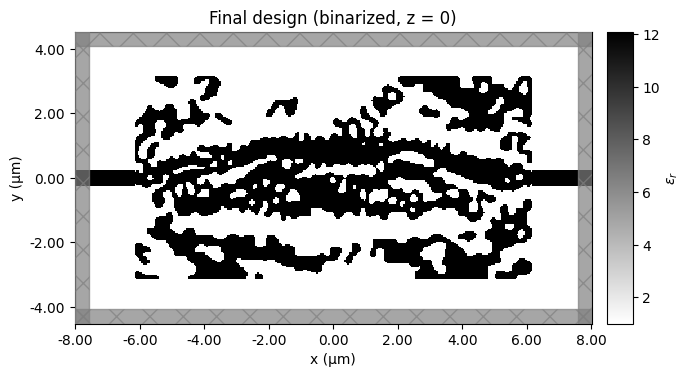

In [18]:
# Section 16 - Convergence plot + final design eps map

obj_vals  = np.array(history_dict["values"])
final_par = history_dict["params"][-1]
final_beta = history_dict["beta"][-1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(obj_vals, "ro-", ms=4)
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective J  (|Tr|^2 - lambda * penalty)")
ax.set_title(f"Convergence - final J = {obj_vals[-1]:.4f}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sim_final = make_adjoint_sim(final_par, beta=final_beta, source="TE", binarize=True)
sim_final.plot_eps(z=0, source_alpha=0, monitor_alpha=0, ax=ax)
ax.set_title("Final design (binarized, z = 0)")
plt.tight_layout()
plt.show()


09:14:13 PDT Created task 'final_TE' with resource_id                           
             'fdve-fbad6881-9c19-4e86-8060-6cbb46b32875' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=358696;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fbad6881-9c19-4e86-8060-6cbb46b32875\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=501350;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fbad6881-9c19-4e86-8060-6cbb46b32875\taskId]8;;\]8;id=358696;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fbad6881-9c19-4e86-8060-6cbb46b32875\=]8;;\]8;id=885691;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fbad6881-9c19-4e86-8060-6cbb46b32875\fdve]8;;\]8;id=358696;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fbad6881-9c19-4e86-8060-6cbb46b32875\-fbad6881-9c1]8;;\
             ]8;id=358696;https://tidy3d.simulation.cloud/workbench?taskId=fdve-fbad6881-9c19-4e86-8060-6cbb46b32875\9-4e86-8060-6cbb46b32875']8;;\.

             Task folder: ]8;id=454125;https://tidy3d.simulation.cloud/folders/folder-7235af3d-4647-4197-8600-06fd43d27c0f\'default']8;;\.

Output()

09:14:14 PDT Estimated FlexCredit cost: 0.326. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

09:15:42 PDT status = success

09:15:44 PDT View simulation result at                                          
             ]8;id=78698;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d463e73c-9cd0-4556-9d86-81e0f84a7391\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=213580;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d463e73c-9cd0-4556-9d86-81e0f84a7391\taskId]8;;\]8;id=78698;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d463e73c-9cd0-4556-9d86-81e0f84a7391\=]8;;\]8;id=191529;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d463e73c-9cd0-4556-9d86-81e0f84a7391\fdve]8;;\]8;id=78698;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d463e73c-9cd0-4556-9d86-81e0f84a7391\-d463e73c-9cd]8;;\
             ]8;id=78698;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d463e73c-9cd0-4556-9d86-81e0f84a7391\0-4556-9d86-81e0f84a7391']8;;\.

Output()

09:15:45 PDT Loading simulation from data/final_TM.hdf5

U_target =
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]

U_meas =
[[-0.6334+0.1166j -0.3431-0.0465j]
 [-0.392 -0.0303j  0.6019+0.196j ]]

|U_target - U_meas| (elementwise) =
[[1.3456 1.0512]
 [1.0995 1.3236]]

Tr(U_target^H U_meas)          = -1.3933-0.1105j
Fidelity  F = |Tr|^2 / 4       = 0.4884    (1.0 = perfect)
Transmission  ||U_meas||_F^2/2 = 0.5450  (1.0 = lossless)
Unitarity residual ||U^H U-I|| = 0.6460  (0.0 = unitary)


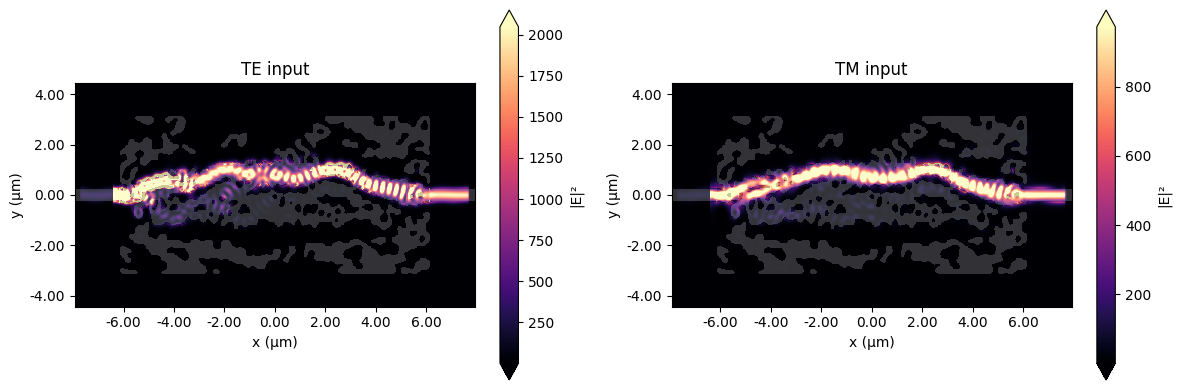

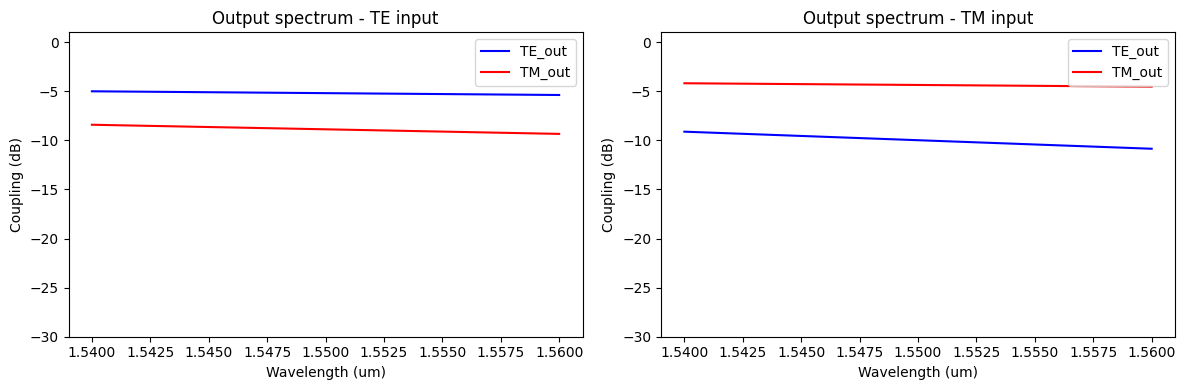

In [19]:
# Section 17 - Verification 1: extract U_meas on the final binarized design

def extract_U(params, beta, binarize=True, extra_monitors=None):
    """Run two FDTDs (TE input, TM input) and return the 2x2 measured unitary.

    Uses the strict *_final settings from Section 2 so the report card is
    accurate, not the loose opt-loop defaults.
    """
    if extra_monitors is None:
        extra_monitors = []

    final_kwargs = dict(
        shutoff=shutoff_final,
        min_steps_per_wvl=min_steps_per_wvl_final,
        num_freqs_src=num_freqs_src_final,
        run_time_sim=run_time_final,
    )

    sim_TE = make_adjoint_sim(params, beta, source="TE", binarize=binarize, **final_kwargs).updated_copy(
        monitors=[out_monitor, out_monitor_bb, field_xy] + extra_monitors,
    )
    sim_TM = make_adjoint_sim(params, beta, source="TM", binarize=binarize, **final_kwargs).updated_copy(
        monitors=[out_monitor, out_monitor_bb, field_xy] + extra_monitors,
    )

    job_TE = web.Job(simulation=sim_TE, task_name="final_TE")
    job_TM = web.Job(simulation=sim_TM, task_name="final_TM")
    data_TE = job_TE.run(path="data/final_TE.hdf5")
    data_TM = job_TM.run(path="data/final_TM.hdf5")

    def _col_np(sim_data):
        amps = sim_data["out_amps"].amps.sel(direction="+", f=freq)
        return np.array([
            complex(amps.sel(mode_index=mode_index_TE).values),
            complex(amps.sel(mode_index=mode_index_TM).values),
        ])

    U_meas = np.stack([_col_np(data_TE), _col_np(data_TM)], axis=1)
    return U_meas, data_TE, data_TM

U_meas, data_TE_final, data_TM_final = extract_U(final_par, final_beta, binarize=True)

# Report card.
print("U_target =")
print(U_target)
print()
print("U_meas =")
print(np.round(U_meas, 4))
print()
print("|U_target - U_meas| (elementwise) =")
print(np.round(np.abs(U_target - U_meas), 4))
print()

trace_overlap = np.trace(U_target.conj().T @ U_meas)
fidelity = float(np.abs(trace_overlap) ** 2 / 4.0)
transmission = float(np.linalg.norm(U_meas, "fro") ** 2 / 2.0)
unitarity_resid = float(np.linalg.norm(U_meas.conj().T @ U_meas - np.eye(2), "fro"))

print(f"Tr(U_target^H U_meas)          = {trace_overlap:.4f}")
print(f"Fidelity  F = |Tr|^2 / 4       = {fidelity:.4f}    (1.0 = perfect)")
print(f"Transmission  ||U_meas||_F^2/2 = {transmission:.4f}  (1.0 = lossless)")
print(f"Unitarity residual ||U^H U-I|| = {unitarity_resid:.4f}  (0.0 = unitary)")

# Visualize steady-state field for both inputs.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
for ax, data, title in zip(axes, [data_TE_final, data_TM_final], ["TE input", "TM input"]):
    data.plot_field("field_xy", "E", "abs^2", ax=ax)
    ax.set_title(title)
plt.show()

# Broadband insertion loss per output mode for each input.
def power_db(sim_data, mode_index):
    amps = sim_data["out_amps_bb"].amps.sel(direction="+", mode_index=mode_index)
    return 10 * np.log10(np.abs(amps.values) ** 2 + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
for ax, data, title in zip(axes, [data_TE_final, data_TM_final], ["TE input", "TM input"]):
    ax.plot(wl_range, power_db(data, mode_index_TE), "-b", label="TE_out")
    ax.plot(wl_range, power_db(data, mode_index_TM), "-r", label="TM_out")
    ax.set_xlabel("Wavelength (um)")
    ax.set_ylabel("Coupling (dB)")
    ax.set_ylim(-30, 1)
    ax.set_title(f"Output spectrum - {title}")
    ax.legend()
plt.show()

In [21]:
# Section 18 - Verification 2: propagate canonical input states
#
# For each of six input states |psi_in> we compute U_target |psi_in> analytically,
# launch a sim that drives both modes simultaneously with the right amplitude and
# phase, and compare to the analytical prediction.

states = {
    "TE":         np.array([1.0, 0.0],          dtype=complex),
    "TM":         np.array([0.0, 1.0],          dtype=complex),
    "diag+":      np.array([1.0,  1.0],         dtype=complex) / np.sqrt(2),
    "diag-":      np.array([1.0, -1.0],         dtype=complex) / np.sqrt(2),
    "Rcirc":      np.array([1.0,  1j],          dtype=complex) / np.sqrt(2),
    "Lcirc":      np.array([1.0, -1j],          dtype=complex) / np.sqrt(2),
}

def make_state_sim(psi_in, params, beta, binarize=True):
    """Build a sim that drives both modes with the amplitude/phase of psi_in.

    Uses the strict *_final cost-control values from Section 2 (verification quality).
    """
    eps = get_eps(params, beta, binarize)
    design_structure = update_design(eps)

    adjoint_dr_mesh = td.MeshOverrideStructure(
        geometry=td.Box(center=(dr_center_x, 0, 0), size=(dr_size_x, dr_size_y, w_thick)),
        dl=[fdtd_design_dl, fdtd_design_dl, fdtd_design_dl],
        enforce=True,
    )

    src_te = td.ModeSource(
        center=[mon_pos_x_in, 0, 0],
        size=[0, mon_w, mon_h],
        source_time=td.GaussianPulse(
            freq0=freq, fwidth=freqw,
            amplitude=float(np.abs(psi_in[0])),
            phase=float(np.angle(psi_in[0])),
        ),
        mode_spec=mode_spec_2,
        mode_index=mode_index_TE,
        direction="+",
        num_freqs=num_freqs_src_final,
    )
    src_tm = td.ModeSource(
        center=[mon_pos_x_in, 0, 0],
        size=[0, mon_w, mon_h],
        source_time=td.GaussianPulse(
            freq0=freq, fwidth=freqw,
            amplitude=float(np.abs(psi_in[1])),
            phase=float(np.angle(psi_in[1])),
        ),
        mode_spec=mode_spec_2,
        mode_index=mode_index_TM,
        direction="+",
        num_freqs=num_freqs_src_final,
    )

    # Normalize by whichever source has the larger amplitude; tidy3d rejects
    # normalize_index pointing to a zero-amplitude source (e.g. pure-TM input).
    normalize_index = 0 if float(np.abs(psi_in[0])) >= float(np.abs(psi_in[1])) else 1

    return td.Simulation(
        size=[size_x, size_y, size_z],
        center=[0, 0, -center_z],
        grid_spec=td.GridSpec.auto(
            wavelength=wl_max,
            min_steps_per_wvl=min_steps_per_wvl_final,
            override_structures=[adjoint_dr_mesh],
        ),
        symmetry=(0, 0, 0),
        structures=[waveguide_in, waveguide_out, sio2_substrate, si_substrate] + design_structure,
        sources=[src_te, src_tm],
        monitors=[out_monitor],
        run_time=run_time_final,
        shutoff=shutoff_final,
        subpixel=True,
        normalize_index=normalize_index,
    )

state_results = {}
print(f"{'state':<8} {'F_state':>9} {'phi_meas':>10} {'phi_target':>12}")
print("-" * 44)
for name, psi_in in states.items():
    sim = make_state_sim(psi_in, final_par, final_beta, binarize=True)
    job = web.Job(simulation=sim, task_name=f"state_{name}")
    data = job.run(path=f"data/state_{name}.hdf5")
    amps = data["out_amps"].amps.sel(direction="+", f=freq)
    psi_out_meas = np.array([
        complex(amps.sel(mode_index=mode_index_TE).values),
        complex(amps.sel(mode_index=mode_index_TM).values),
    ])
    psi_out_target = U_target @ psi_in
    # State fidelity, gauge-invariant.
    F_state = float(np.abs(np.vdot(psi_out_target, psi_out_meas)) ** 2 /
                    (np.vdot(psi_out_target, psi_out_target).real
                     * np.vdot(psi_out_meas, psi_out_meas).real + 1e-30))
    # Global phase difference (for diagnostics; should be roughly constant across states).
    inner = np.vdot(psi_out_target, psi_out_meas)
    phi_meas = float(np.angle(inner))
    state_results[name] = dict(
        psi_in=psi_in, psi_out_meas=psi_out_meas, psi_out_target=psi_out_target, F=F_state, phi=phi_meas,
    )
    print(f"{name:<8} {F_state:>9.4f} {np.degrees(phi_meas):>9.1f} deg   (target: e^{{i phi}} arbitrary)")

state      F_state   phi_meas   phi_target
--------------------------------------------


10:38:04 PDT Created task 'state_TE' with resource_id                           
             'fdve-54a8a56d-4f3d-4a15-af08-80e97502961f' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=14306;https://tidy3d.simulation.cloud/workbench?taskId=fdve-54a8a56d-4f3d-4a15-af08-80e97502961f\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=150479;https://tidy3d.simulation.cloud/workbench?taskId=fdve-54a8a56d-4f3d-4a15-af08-80e97502961f\taskId]8;;\]8;id=14306;https://tidy3d.simulation.cloud/workbench?taskId=fdve-54a8a56d-4f3d-4a15-af08-80e97502961f\=]8;;\]8;id=815542;https://tidy3d.simulation.cloud/workbench?taskId=fdve-54a8a56d-4f3d-4a15-af08-80e97502961f\fdve]8;;\]8;id=14306;https://tidy3d.simulation.cloud/workbench?taskId=fdve-54a8a56d-4f3d-4a15-af08-80e97502961f\-54a8a56d-4f3]8;;\
             ]8;id=14306;https://tidy3d.simulation.cloud/workbench?taskId=fdve-54a8a56d-4f3d-4a15-af08-80e97502961f\d-4a15-af08-80e97502961f']8;;\.

             Task folder: ]8;id=722671;https://tidy3d.simulation.cloud/folders/folder-7235af3d-4647-4197-8600-06fd43d27c0f\'default']8;;\.

Output()

...

10:42:02 PDT status = success

10:42:04 PDT View simulation result at                                          
             ]8;id=925718;https://tidy3d.simulation.cloud/workbench?taskId=fdve-23e6ef27-77ed-4860-a2a8-1bd75fb87069\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=278174;https://tidy3d.simulation.cloud/workbench?taskId=fdve-23e6ef27-77ed-4860-a2a8-1bd75fb87069\taskId]8;;\]8;id=925718;https://tidy3d.simulation.cloud/workbench?taskId=fdve-23e6ef27-77ed-4860-a2a8-1bd75fb87069\=]8;;\]8;id=671453;https://tidy3d.simulation.cloud/workbench?taskId=fdve-23e6ef27-77ed-4860-a2a8-1bd75fb87069\fdve]8;;\]8;id=925718;https://tidy3d.simulation.cloud/workbench?taskId=fdve-23e6ef27-77ed-4860-a2a8-1bd75fb87069\-23e6ef27-77e]8;;\
             ]8;id=925718;https://tidy3d.simulation.cloud/workbench?taskId=fdve-23e6ef27-77ed-4860-a2a8-1bd75fb87069\d-4860-a2a8-1bd75fb87069']8;;\.

Output()

             Loading simulation from data/state_Lcirc.hdf5

Lcirc       0.9679    -161.5 deg   (target: e^{i phi} arbitrary)


In [22]:
# Section 19 - Verification 3: rotator-retarder analytical decomposition
#
# Hadamard has multiple R-D-R decompositions; one is
#     H = R(-pi/4) D(pi) R(pi/4)
# up to an overall phase. Multiply it out symbolically and compare to U_target.

alpha1 =  np.pi / 4
phi    =  np.pi
alpha2 = -np.pi / 4
U_cascade = rotator(alpha2) @ retarder(phi) @ rotator(alpha1)

# Hadamard equals U_cascade up to a global phase factor e^{i pi/2} = i.
# Verify by computing |Tr(U_target^H U_cascade)|^2 / 4 = 1 if they match modulo phase.
phase_match = np.abs(np.trace(U_target.conj().T @ U_cascade)) ** 2 / 4.0

print("Analytical cascade  U = R(-pi/4) D(pi) R(pi/4) =")
print(np.round(U_cascade, 4))
print()
print(f"|Tr(U_target^H U_cascade)|^2 / 4 = {phase_match:.4f}    (1.0 = same unitary up to phase)")
print()
print("So the inverse-designed device, the analytical R-D-R cascade, and the")
print("Hadamard target all implement the same operation on (a_TE, a_TM) up to a")
print("global phase factor that has no physical effect on the output state.")

Analytical cascade  U = R(-pi/4) D(pi) R(pi/4) =
[[ 0.+0.j -1.+0.j]
 [-1.+0.j -0.+0.j]]

|Tr(U_target^H U_cascade)|^2 / 4 = 0.5000    (1.0 = same unitary up to phase)

So the inverse-designed device, the analytical R-D-R cascade, and the
Hadamard target all implement the same operation on (a_TE, a_TM) up to a
global phase factor that has no physical effect on the output state.


In [ ]:
# Section 20 - GDS export + summary

sim_final.to_gds_file(
    fname="misc/polarization_unitary.gds",
    z=0,
    permittivity_threshold=(eps_min + eps_max) / 2,
    frequency=freq,
)

print("=" * 60)
print("Final summary")
print("=" * 60)
print(f"Target unitary       : Hadamard")
print(f"Wavelength           : {wl} um")
print(f"Design region        : {dr_size_x:.2f} um x {dr_size_y:.2f} um, {nx} x {ny} pixels")
print(f"Optimization iters   : {total_iter}")
print(f"Final objective J    : {obj_vals[-1]:.4f}")
print(f"Fidelity F           : {fidelity:.4f}")
print(f"Transmission T       : {transmission:.4f}")
print(f"Unitarity residual   : {unitarity_resid:.4f}")
print(f"GDS exported to      : misc/polarization_unitary.gds")